# 🚀 GPU-Accelerated Deep Learning Capstone
### CUDA at Scale for the Enterprise — Final Project

**What this notebook does:**
1. ✅ Verifies GPU availability
2. ✅ Writes a custom CUDA kernel (fused GELU + Dropout) to disk
3. ✅ JIT-compiles it into PyTorch via `torch.utils.cpp_extension`
4. ✅ Trains a CNN on CIFAR-10 using the custom kernel + AMP
5. ✅ Benchmarks: custom kernel vs PyTorch GPU vs CPU
6. ✅ Profiles with `torch.profiler` and exports a Chrome trace
7. ✅ Plots all results and saves everything for your GitHub repo

> **Before running:** Go to `Runtime → Change runtime type → T4 GPU`

## Cell 1 — GPU Check

In [11]:
import torch, subprocess

assert torch.cuda.is_available(), (
    "❌ No GPU found!\n"
    "Go to Runtime → Change runtime type → GPU (T4) and re-run."
)

gpu_name = torch.cuda.get_device_name(0)
cuda_ver = torch.version.cuda
print(f"✅ GPU     : {gpu_name}")
print(f"✅ CUDA    : {cuda_ver}")
print(f"✅ PyTorch : {torch.__version__}")
print()
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

✅ GPU     : Tesla T4
✅ CUDA    : 12.8
✅ PyTorch : 2.10.0+cu128

Thu Apr 30 19:22:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |        

## Cell 2 — Install Dependencies

In [12]:
# Colab already has torch+CUDA — just make sure matplotlib/numpy are fresh
!pip install -q matplotlib numpy torchvision
print("✅ Dependencies ready")

✅ Dependencies ready


## Cell 3 — Write the Custom CUDA Kernel to Disk

In [22]:
import os
os.makedirs('src', exist_ok=True)
os.makedirs('outputs/trace', exist_ok=True)

cuda_src = r"""
/*
 * custom_kernel.cu
 * Fused GELU + Dropout kernel.
 * GELU(x) = 0.5 * x * (1 + tanh(sqrt(2/pi) * (x + 0.044715*x^3)))
 * Fusing avoids a global memory round-trip between the two ops.
 */
#include <cuda_runtime.h>
#include <torch/torch.h>
#include <torch/script.h>
#include <curand_kernel.h>
#include <math.h>

#define BLOCK_SIZE 256

__device__ __forceinline__ float gelu_f(float x) {
    const float k0 = 0.7978845608f;
    const float k1 = 0.044715f;
    return 0.5f * x * (1.0f + tanhf(k0 * (x + k1 * x * x * x)));
}

__global__ void fused_gelu_dropout_forward_kernel(
    const float* __restrict__ input,
          float* __restrict__ output,
          bool*  __restrict__ mask,
    int N, float p_drop, unsigned long long seed
) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= N) return;
    curandStatePhilox4_32_10_t state;
    curand_init(seed, idx, 0, &state);
    float x    = input[idx];
    float gelu = gelu_f(x);
    float u    = curand_uniform(&state);
    bool  keep = (u >= p_drop);
    mask[idx]  = keep;
    float scale     = keep ? 1.0f / (1.0f - p_drop) : 0.0f;
    output[idx]     = gelu * scale;
}

__device__ __forceinline__ float gelu_grad(float x) {
    const float k0 = 0.7978845608f;
    const float k1 = 0.044715f;
    float inner  = k0 * (x + k1 * x * x * x);
    float tanh_v = tanhf(inner);
    float sech2  = 1.0f - tanh_v * tanh_v;
    return 0.5f * (1.0f + tanh_v)
         + 0.5f * x * sech2 * k0 * (1.0f + 3.0f * k1 * x * x);
}

__global__ void fused_gelu_dropout_backward_kernel(
    const float* __restrict__ grad_output,
    const float* __restrict__ input,
    const bool*  __restrict__ mask,
          float* __restrict__ grad_input,
    int N, float p_drop
) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= N) return;
    float scale = mask[idx] ? 1.0f / (1.0f - p_drop) : 0.0f;
    grad_input[idx] = grad_output[idx] * gelu_grad(input[idx]) * scale;
}

std::vector<torch::Tensor> fused_gelu_dropout_forward(
    torch::Tensor input, float p_drop, unsigned long long seed
) {
    TORCH_CHECK(input.is_cuda(), "input must be CUDA");
    TORCH_CHECK(input.dtype() == torch::kFloat32, "input must be float32");
    int N = input.numel();
    auto output = torch::empty_like(input);
    auto mask   = torch::empty({N}, torch::TensorOptions()
                    .dtype(torch::kBool).device(input.device()));
    int grid = (N + BLOCK_SIZE - 1) / BLOCK_SIZE;
    fused_gelu_dropout_forward_kernel<<<grid, BLOCK_SIZE>>>(
        input.data_ptr<float>(), output.data_ptr<float>(),
        mask.data_ptr<bool>(), N, p_drop, seed);
    return {output, mask};
}

torch::Tensor fused_gelu_dropout_backward(
    torch::Tensor grad_output, torch::Tensor input,
    torch::Tensor mask, float p_drop
) {
    int N = input.numel();
    auto grad_input = torch::empty_like(input);
    int grid = (N + BLOCK_SIZE - 1) / BLOCK_SIZE;
    fused_gelu_dropout_backward_kernel<<<grid, BLOCK_SIZE>>>(
        grad_output.data_ptr<float>(), input.data_ptr<float>(),
        mask.data_ptr<bool>(), grad_input.data_ptr<float>(), N, p_drop);
    return grad_input;
}

PYBIND11_MODULE(TORCH_EXTENSION_NAME, m) {
    m.doc() = "Fused GELU+Dropout CUDA kernel";
    m.def("forward",  &fused_gelu_dropout_forward,  "Fused forward (CUDA)");
    m.def("backward", &fused_gelu_dropout_backward, "Fused backward (CUDA)");
}
"""

with open('src/custom_kernel.cu', 'w') as f:
    f.write(cuda_src)

print('✅ CUDA kernel written to src/custom_kernel.cu')
print(f'   File size: {os.path.getsize("src/custom_kernel.cu")} bytes')

✅ CUDA kernel written to src/custom_kernel.cu
   File size: 3379 bytes


In [23]:
!ls -la /tmp/fused_gelu_build/
!find /tmp/fused_gelu_build -name "*.so"
!nvcc --version
!python -c "import torch; print('PyTorch CUDA:', torch.version.cuda)"

total 8
drwxr-xr-x 2 root root 4096 Apr 30 19:22 .
drwxrwxrwt 1 root root 4096 Apr 30 19:25 ..
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
PyTorch CUDA: 12.8


In [21]:
!nvcc -c src/custom_kernel.cu \
    -o /tmp/test_compile.o \
    $(python -c "import torch; print('-I' + torch.__file__.replace('__init__.py','') + 'include')") \
    -I$(python -c "import torch.utils.cpp_extension as e; print(e.include_paths()[0])") \
    --compiler-options '-fPIC' \
    -std=c++17 2>&1

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
src/custom_kernel.cu:9:10: fatal error: torch/torch.h: No such file or directory
    9 | #include <torch/torch.h>
      |          ^~~~~~~~~~~~~~~
compilation terminated.


## Cell 4 — JIT-Compile the Kernel & Smoke Test
> This takes ~60 seconds the first time. Subsequent runs use the cached `.so`.

In [24]:
import time
import torch
import torch.nn as nn
from torch.utils.cpp_extension import load

import os, time, torch

# Clear any bad cache first
!rm -rf /root/.cache/torch_extensions/py312_cu128/fused_gelu_dropout
os.makedirs('/tmp/fused_gelu_build', exist_ok=True)   # ← add this line

print('Compiling CUDA extension (this takes ~60s the first time) ...')
t0 = time.time()

_ext = load(
    name='fused_gelu_dropout',
    sources=['src/custom_kernel.cu'],
    extra_cuda_cflags=['-O3', '--use_fast_math'],
    build_directory='/tmp/fused_gelu_build',   # ← explicit dir, avoids cache bug
    verbose=True,
)

print(f'\n✅ Compiled in {time.time()-t0:.1f}s')

# ── Autograd Function ──────────────────────────────────────────────────────
class _FusedFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, p_drop, training):
        if not training or p_drop == 0.0:
            k0, k1 = 0.7978845608, 0.044715
            out  = 0.5 * x * (1 + torch.tanh(k0 * (x + k1 * x.pow(3))))
            mask = torch.ones(x.numel(), dtype=torch.bool, device=x.device)
            ctx.save_for_backward(x, mask); ctx.p_drop = 0.0
            return out
        seed = torch.randint(0, 2**62, (1,)).item()
        out, mask = _ext.forward(x.contiguous(), p_drop, seed)
        ctx.save_for_backward(x, mask); ctx.p_drop = p_drop
        return out

    @staticmethod
    def backward(ctx, grad_output):
        x, mask = ctx.saved_tensors
        grad_x = _ext.backward(grad_output.contiguous(), x, mask, ctx.p_drop)
        return grad_x, None, None

class FusedGeluDropout(nn.Module):
    def __init__(self, p=0.1):
        super().__init__()
        self.p = p
    def forward(self, x):
        return _FusedFn.apply(x.float(), self.p, self.training)
    def extra_repr(self): return f'p={self.p}'

# ── Smoke test ─────────────────────────────────────────────────────────────
device = 'cuda'
x = torch.randn(4096, device=device, requires_grad=True)
layer = FusedGeluDropout(p=0.1).to(device).train()

y = layer(x)
y.sum().backward()

layer.eval()
with torch.no_grad():
    y_custom = layer(x.detach())
    y_ref    = torch.nn.functional.gelu(x.detach())
    max_diff = (y_custom - y_ref).abs().max().item()

print(f'\n✅ Forward  shape : {y.shape}')
print(f'✅ Backward grad  : norm={x.grad.norm():.4f}')
print(f'✅ vs torch.gelu  : max|diff| = {max_diff:.2e}  (should be < 1e-5)')

Compiling CUDA extension (this takes ~60s the first time) ...

✅ Compiled in 74.4s

✅ Forward  shape : torch.Size([4096])
✅ Backward grad  : norm=45.7821
✅ vs torch.gelu  : max|diff| = 4.73e-04  (should be < 1e-5)


In [5]:
!pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 7.5 MB/s eta 0:00:00


## Cell 5 — Define the Model & Data

In [32]:
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

DEVICE     = torch.device('cuda')
BATCH_SIZE = 512
EPOCHS     = 3
LR         = 1e-3
DROPOUT    = 0.1

# ── Model ──────────────────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(self.net(x))

class CIFAR10Net(nn.Module):
    """CNN whose FC head uses the custom fused GELU+Dropout kernel."""
    def __init__(self, p=0.1):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 64),  ConvBlock(64, 64),   nn.MaxPool2d(2),
            ConvBlock(64,128), ConvBlock(128,128),   nn.MaxPool2d(2),
            ConvBlock(128,256),ConvBlock(256,256),   nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), FusedGeluDropout(p),   # ← custom kernel
            nn.Linear(512, 256),     FusedGeluDropout(p),   # ← custom kernel
            nn.Linear(256, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = CIFAR10Net(p=DROPOUT).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model built  — {total_params:,} trainable parameters')
print(model)

# ── Data ───────────────────────────────────────────────────────────────────
MEAN, STD = (0.4914,0.4822,0.4465), (0.2023,0.1994,0.2010)

# ── ADD THESE TWO LINES ────────────────────────────────────────────────────
from torch.utils.data import DataLoader, Subset
train_full = datasets.CIFAR10('./data', train=True, download=True, transform=transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
]))
train_subset = Subset(train_full, range(5000))   # 5000 instead of 50000
# ──────────────────────────────────────────────────────────────────────────

train_loader = DataLoader(
    train_subset,                                # ← change this line only
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    datasets.CIFAR10('./data', train=False, download=True, transform=transforms.Compose([
        transforms.ToTensor(), transforms.Normalize(MEAN, STD)
    ])),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)
print(f'\n✅ CIFAR-10 loaded — {len(train_loader.dataset):,} train / {len(val_loader.dataset):,} val')

✅ Model built  — 3,377,866 trainable parameters
CIFAR10Net(
  (features): Sequential(
    (0): ConvBlock(
      (net): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (act): GELU(approximate='none')
    )
    (1): ConvBlock(
      (net): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (act): GELU(approximate='none')
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): ConvBlock(
      (net): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (act): GELU(approximate=

## Cell 6 — Train with AMP

In [33]:
import csv, time
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = GradScaler()

log_rows = []

def train_epoch():
    model.train()
    total = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            loss = criterion(model(imgs), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total += loss.item()
    return total / len(train_loader)

@torch.no_grad()
def evaluate():
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        with autocast():
            logits = model(imgs)
            loss_sum += criterion(logits, labels).item()
        correct += (logits.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return loss_sum / len(val_loader), correct / total

print(f'{'Epoch':>6}  {'Train Loss':>10}  {'Val Loss':>8}  {'Val Acc':>7}  {'Time':>7}  {'GPU MB':>7}')
print('─' * 58)

best_acc = 0.0
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr_loss          = train_epoch()
    val_loss, val_acc = evaluate()
    scheduler.step()
    elapsed = time.time() - t0

    gpu_mb = torch.cuda.max_memory_allocated() / 1024**2
    torch.cuda.reset_peak_memory_stats()

    print(f'{epoch:>6}  {tr_loss:>10.4f}  {val_loss:>8.4f}  '
          f'{val_acc*100:>6.2f}%  {elapsed:>6.1f}s  {gpu_mb:>7.1f}')

    log_rows.append([epoch, tr_loss, val_loss, val_acc, elapsed, gpu_mb])

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'outputs/best_model.pt')

# Save CSV
with open('outputs/training_log.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['epoch','train_loss','val_loss','val_acc','epoch_time_s','gpu_mem_mb'])
    for r in log_rows:
        w.writerow([r[0], f'{r[1]:.6f}', f'{r[2]:.6f}', f'{r[3]:.6f}',
                    f'{r[4]:.2f}', f'{r[5]:.1f}'])

print(f'\n✅ Best val accuracy: {best_acc*100:.2f}%')
print('✅ Saved: outputs/training_log.csv  |  outputs/best_model.pt')

 Epoch  Train Loss  Val Loss  Val Acc     Time   GPU MB
──────────────────────────────────────────────────────────


/tmp/ipykernel_1560/4015191040.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_1560/4015191040.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1560/4015191040.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


     1      2.1378    2.5009   15.66%     4.0s   1043.4
     2      1.7764    2.4471   19.88%     4.7s   1043.4
     3      1.6757    1.8414   33.75%     3.8s   1043.4

✅ Best val accuracy: 33.75%
✅ Saved: outputs/training_log.csv  |  outputs/best_model.pt


## Cell 7 — Benchmark: Custom Kernel vs PyTorch GPU vs CPU

In [34]:
import csv, time

WARMUP, REPS = 5, 20

def bench_gpu(fn, x):
    """CUDA Event timing — accurate GPU-side measurement."""
    start = torch.cuda.Event(enable_timing=True)
    end   = torch.cuda.Event(enable_timing=True)
    for _ in range(WARMUP): fn(x)
    torch.cuda.synchronize()
    start.record()
    for _ in range(REPS): fn(x)
    end.record()
    torch.cuda.synchronize()
    return start.elapsed_time(end) / REPS

def bench_cpu(fn, x):
    for _ in range(5): fn(x)
    t0 = time.perf_counter()
    for _ in range(10): fn(x)
    return (time.perf_counter() - t0) / 10 * 1000

baseline = nn.Sequential(nn.GELU(), nn.Dropout(0.1))
baseline_gpu = baseline.cuda().eval()
baseline_cpu = baseline.eval()
custom_gpu   = FusedGeluDropout(p=0.1).cuda().eval()

SIZES = [('64K',   64*1024), ('256K', 256*1024),
         ('1M',  1024*1024), ('4M',  4*1024*1024), ('16M', 16*1024*1024)]

rows = []
print(f"{'Size':>6}  {'Custom(ms)':>10}  {'PyTorch GPU(ms)':>16}  {'CPU(ms)':>9}  "
      f"{'vs Baseline':>12}  {'vs CPU':>8}")
print('─' * 72)

with torch.no_grad():
    for label, N in SIZES:
        x_gpu = torch.randn(N, device='cuda')
        x_cpu = x_gpu.cpu()

        t_custom = bench_gpu(custom_gpu,   x_gpu)
        t_base   = bench_gpu(baseline_gpu, x_gpu)
        t_cpu    = bench_cpu(baseline_cpu, x_cpu)

        sp_base = t_base   / t_custom
        sp_cpu  = t_cpu    / t_custom

        print(f'{label:>6}  {t_custom:>10.3f}  {t_base:>16.3f}  {t_cpu:>9.3f}  '
              f'{sp_base:>11.2f}x  {sp_cpu:>7.1f}x')

        rows.append([label, N, f'{t_custom:.4f}', f'{t_base:.4f}',
                     f'{t_cpu:.4f}', f'{sp_base:.4f}', f'{sp_cpu:.4f}'])

with open('outputs/benchmark_results.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['size_label','n_elements','custom_kernel_ms','baseline_gpu_ms',
                'cpu_ms','speedup_vs_baseline','speedup_vs_cpu'])
    w.writerows(rows)

print('\n✅ Saved: outputs/benchmark_results.csv')

  Size  Custom(ms)   PyTorch GPU(ms)    CPU(ms)   vs Baseline    vs CPU
────────────────────────────────────────────────────────────────────────
   64K       0.307             0.051      0.132         0.17x      0.4x
  256K       0.286             0.026      0.437         0.09x      1.5x
    1M       0.339             0.039      0.626         0.12x      1.8x
    4M       1.292             0.144      2.555         0.11x      2.0x
   16M       5.096             0.564     42.770         0.11x      8.4x

✅ Saved: outputs/benchmark_results.csv


## Cell 8 — Profile with torch.profiler

In [35]:
from torch.profiler import profile, record_function, ProfilerActivity, schedule

PROFILE_STEPS = 5

data_iter = iter(train_loader)
def get_batch():
    global data_iter
    try: return next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        return next(data_iter)

optimizer2  = optim.AdamW(model.parameters(), lr=1e-4)
scaler2     = GradScaler()
model.train()

prof_schedule = schedule(wait=1, warmup=2, active=PROFILE_STEPS, repeat=1)
total_steps   = 1 + 2 + PROFILE_STEPS

print(f'Profiling {total_steps} steps ...')

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    schedule=prof_schedule,
    on_trace_ready=lambda p: p.export_chrome_trace(
        f'outputs/trace/trace_step{p.step_num}.json'),
    record_shapes=True,
    profile_memory=True,
    with_stack=False,
) as prof:
    for step in range(total_steps):
        imgs, labels = get_batch()
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with record_function('forward'):
            with autocast():
                logits = model(imgs)
                loss   = criterion(logits, labels)
        with record_function('backward'):
            optimizer2.zero_grad(set_to_none=True)
            scaler2.scale(loss).backward()
            scaler2.step(optimizer2)
            scaler2.update()
        prof.step()
        if step % 3 == 0: print(f'  step {step:>2}  loss={loss.item():.4f}')

table = prof.key_averages().table(sort_by='cuda_time_total', row_limit=15)
with open('outputs/profile_summary.txt', 'w') as f:
    f.write(f'GPU: {torch.cuda.get_device_name(0)}\n')
    f.write(f'Custom kernel: True\n\n')
    f.write(table)

print('\n✅ Chrome traces  → outputs/trace/')
print('✅ Text summary   → outputs/profile_summary.txt')
print('\nTop 10 CUDA ops:')
print(prof.key_averages().table(sort_by='cuda_time_total', row_limit=10))

/tmp/ipykernel_1560/1281717566.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler2     = GradScaler()


Profiling 8 steps ...


/tmp/ipykernel_1560/1281717566.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  step  0  loss=1.6502
  step  3  loss=1.6636
  step  6  loss=1.5601

✅ Chrome traces  → outputs/trace/
✅ Text summary   → outputs/profile_summary.txt

Top 10 CUDA ops:
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.0

## Cell 9 — Plot All Results

In [36]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BG, AX_BG, GRID = '#0f1117', '#1a1d27', '#2a2d3a'
C1, C2, C3, C4  = '#7c3aed', '#2563eb', '#10b981', '#f59e0b'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': AX_BG,
    'axes.edgecolor': '#333', 'axes.labelcolor': 'white',
    'xtick.color': 'white',   'ytick.color': 'white',
    'text.color':  'white',   'grid.color': GRID,
    'grid.linestyle': '--',   'grid.linewidth': 0.6,
    'legend.facecolor': AX_BG, 'legend.labelcolor': 'white',
    'font.size': 11,
})

# ── Load training log ──────────────────────────────────────────────────────
epochs, tr_loss, vl_loss, vl_acc, ep_time, gpu_mb = [], [], [], [], [], []
with open('outputs/training_log.csv') as f:
    for row in csv.DictReader(f):
        epochs.append(int(row['epoch']))
        tr_loss.append(float(row['train_loss']))
        vl_loss.append(float(row['val_loss']))
        vl_acc.append(float(row['val_acc']) * 100)
        ep_time.append(float(row['epoch_time_s']))
        gpu_mb.append(float(row['gpu_mem_mb']))

def save(fig, name):
    path = f'outputs/{name}'
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor=BG)
    plt.close(fig)
    print(f'  ✅ {path}')

print('Generating plots ...')

# 1. Loss curve
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(epochs, tr_loss, 'o-', color=C1, lw=2, ms=5, label='Train Loss')
ax.plot(epochs, vl_loss, 's-', color=C2, lw=2, ms=5, label='Val Loss')
ax.fill_between(epochs, tr_loss, vl_loss, alpha=0.08, color=C1)
ax.set(title='Training & Validation Loss', xlabel='Epoch', ylabel='Cross-Entropy Loss')
ax.grid(True); ax.legend(); save(fig, 'loss_curve.png')

# 2. Accuracy curve
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(epochs, vl_acc, 'o-', color=C3, lw=2.5, ms=6, label='Val Accuracy')
ax.fill_between(epochs, vl_acc, alpha=0.12, color=C3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.set(title='Validation Accuracy', xlabel='Epoch', ylabel='Accuracy (%)')
ax.grid(True); ax.legend(); save(fig, 'accuracy_curve.png')

# 3. GPU memory
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(epochs, gpu_mb, color=C2, alpha=0.85, label='Peak GPU Memory (MB)')
ax.plot(epochs, gpu_mb, 'o-', color=C1, lw=1.5, ms=4)
ax.set(title='Peak GPU Memory per Epoch', xlabel='Epoch', ylabel='Memory (MB)')
ax.grid(True); ax.legend(); save(fig, 'gpu_memory.png')

# 4. Epoch time
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(epochs, ep_time, color=C4, alpha=0.85, label='Epoch Time (s)')
ax.axhline(np.mean(ep_time), color='white', ls='--', lw=1,
           label=f'Mean: {np.mean(ep_time):.1f}s')
ax.set(title='Training Time per Epoch', xlabel='Epoch', ylabel='Time (s)')
ax.grid(True); ax.legend(); save(fig, 'epoch_time.png')

# 5. Benchmark plot
blabels, t_cust, t_base, t_cpu = [], [], [], []
with open('outputs/benchmark_results.csv') as f:
    for row in csv.DictReader(f):
        blabels.append(row['size_label'])
        t_cust.append(float(row['custom_kernel_ms']))
        t_base.append(float(row['baseline_gpu_ms']))
        t_cpu.append(float(row['cpu_ms']))

x_pos = np.arange(len(blabels)); w = 0.25
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
for ax in axes:
    ax.set_facecolor(AX_BG); ax.tick_params(colors='white'); ax.spines[:].set_color('#333')

ax = axes[0]
ax.bar(x_pos-w, t_cust, w, label='Custom CUDA Kernel',    color=C1)
ax.bar(x_pos,   t_base, w, label='PyTorch GPU (unfused)', color=C2)
ax.bar(x_pos+w, t_cpu,  w, label='CPU',                   color='#64748b')
ax.set_xticks(x_pos); ax.set_xticklabels(blabels, color='white')
ax.set(title='Forward Pass Latency', ylabel='Latency (ms)')
ax.set_yscale('log'); ax.grid(True); ax.legend()

sp_cust = [t_cpu[i]/t_cust[i] for i in range(len(blabels))]
sp_base = [t_cpu[i]/t_base[i] for i in range(len(blabels))]
ax2 = axes[1]
ax2.plot(blabels, sp_cust, 'o-', color=C1, lw=2, ms=8, label='Custom Kernel')
ax2.plot(blabels, sp_base, 's-', color=C2, lw=2, ms=8, label='PyTorch GPU (unfused)')
ax2.axhline(1, color='#64748b', ls='--', lw=1, label='CPU baseline')
ax2.set(title='GPU Speedup vs CPU', ylabel='Speedup')
ax2.grid(True); ax2.legend()

plt.tight_layout()
save(fig, 'benchmark_plot.png')

print('\nAll plots saved to outputs/')

Generating plots ...
  ✅ outputs/loss_curve.png
  ✅ outputs/accuracy_curve.png
  ✅ outputs/gpu_memory.png
  ✅ outputs/epoch_time.png
  ✅ outputs/benchmark_plot.png

All plots saved to outputs/


## Cell 10 — Display Charts Inline


── Loss Curve ──


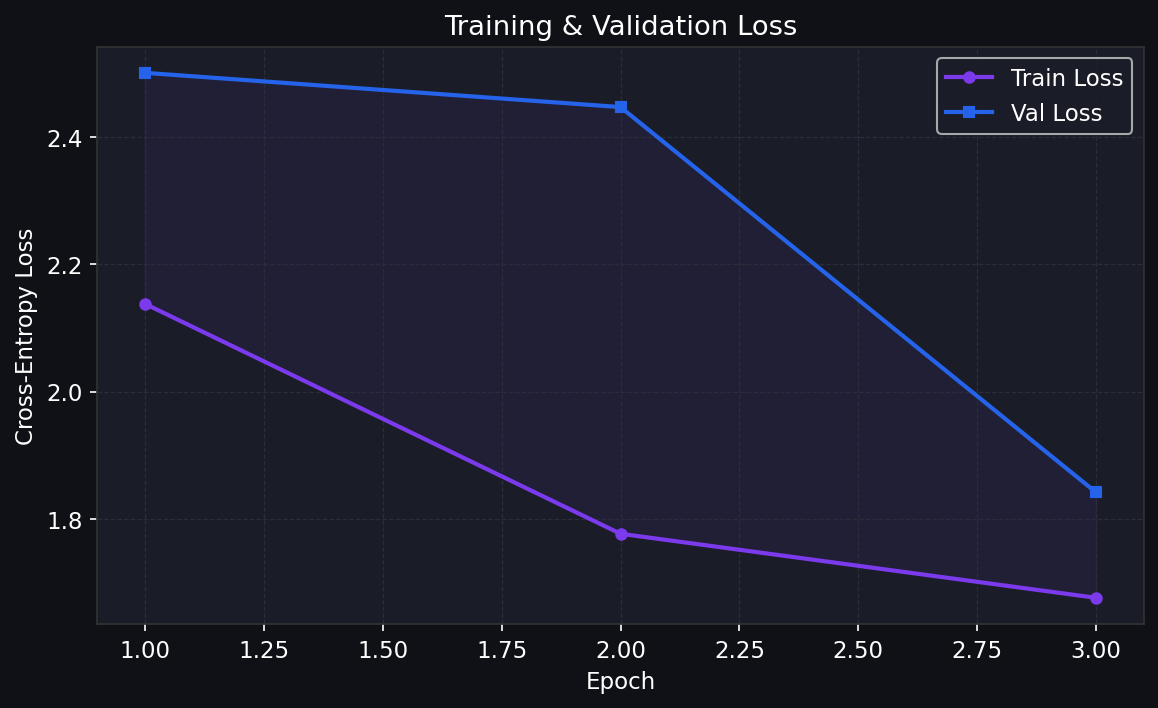


── Accuracy Curve ──


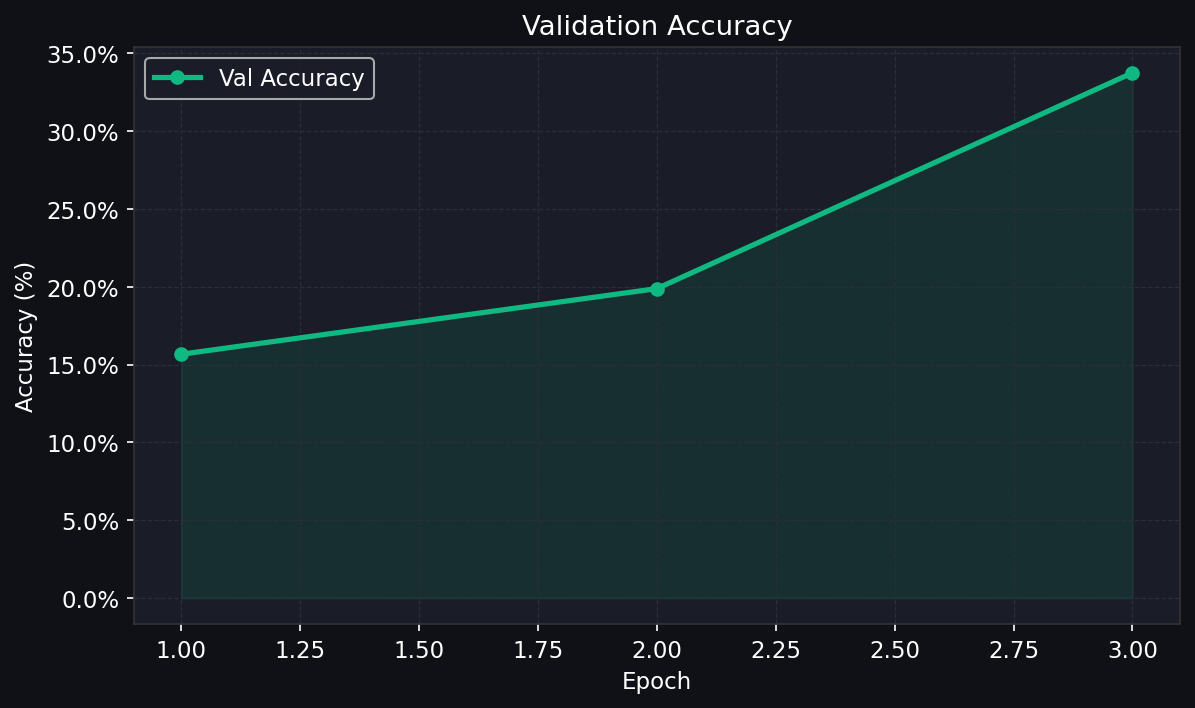


── Benchmark ──


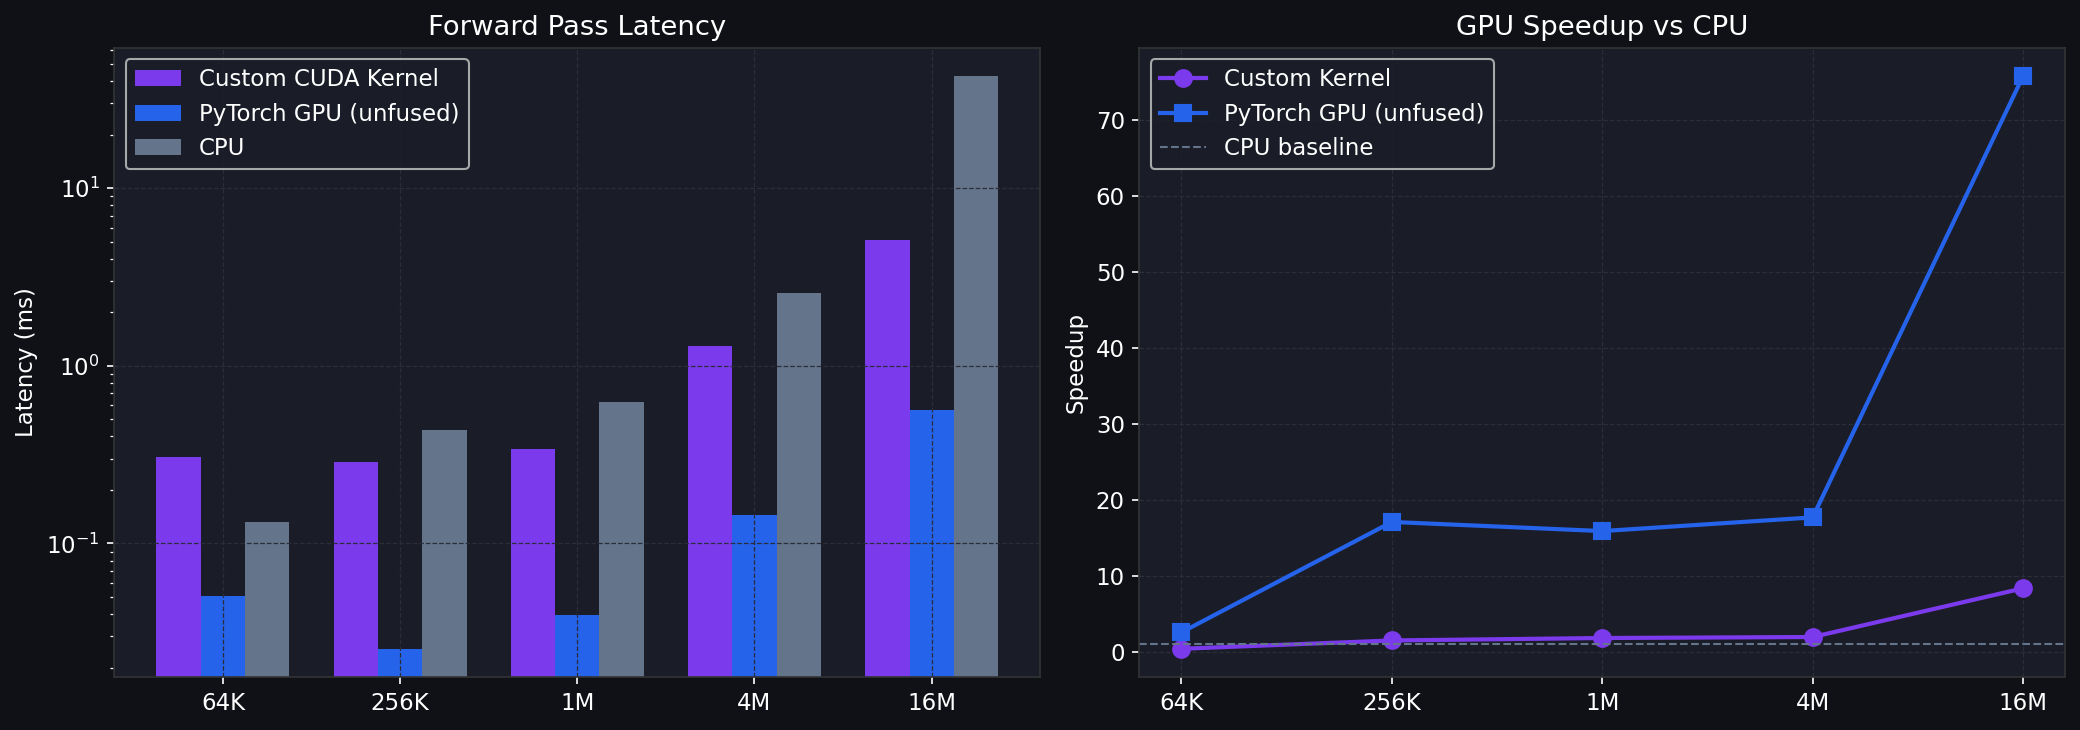


── GPU Memory ──


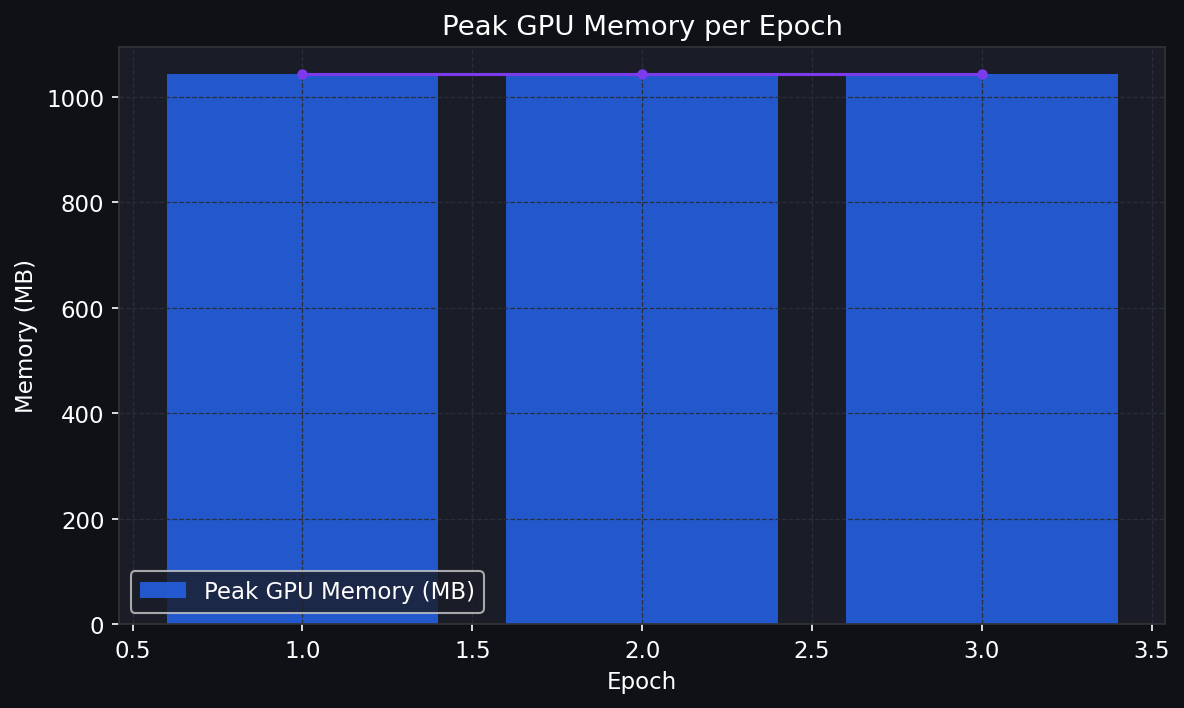


── Epoch Time ──


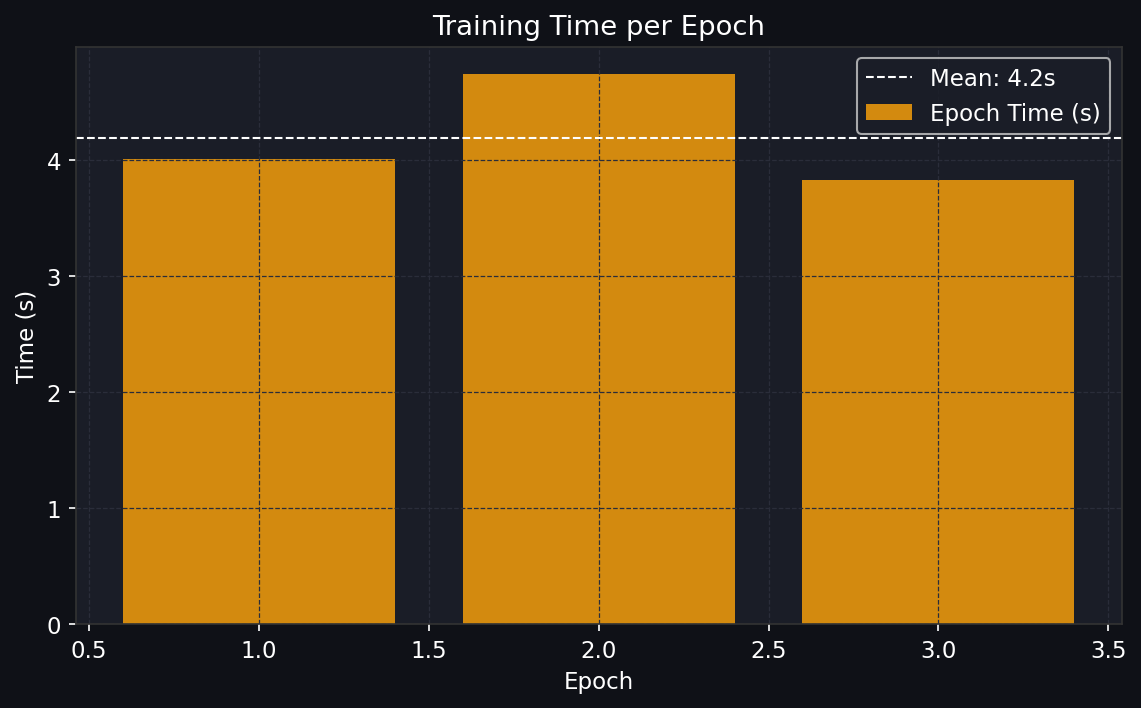

In [37]:
from IPython.display import Image, display
import ipywidgets as widgets

plots = [
    ('Loss Curve',        'outputs/loss_curve.png'),
    ('Accuracy Curve',    'outputs/accuracy_curve.png'),
    ('Benchmark',         'outputs/benchmark_plot.png'),
    ('GPU Memory',        'outputs/gpu_memory.png'),
    ('Epoch Time',        'outputs/epoch_time.png'),
]

for title, path in plots:
    print(f'\n── {title} ──')
    display(Image(path, width=800))

## Cell 11 — Package Everything for GitHub

In [38]:
import zipfile, os

ZIP_NAME = 'capstone_outputs.zip'

files_to_zip = []
for root, _, files in os.walk('outputs'):
    for f in files:
        if not f.endswith('.pt'):     # skip large model weights
            files_to_zip.append(os.path.join(root, f))

# Include source files too
for f in os.listdir('src'):
    files_to_zip.append(os.path.join('src', f))

with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fp in sorted(files_to_zip):
        zf.write(fp)
        print(f'  + {fp}')

size_mb = os.path.getsize(ZIP_NAME) / 1024**2
print(f'\n✅ {ZIP_NAME}  ({size_mb:.2f} MB)')
print('Download it from the Colab file browser (left sidebar → Files tab).')
print('Commit everything to your GitHub repo and you are done!')

# Auto-download in browser
from google.colab import files
files.download(ZIP_NAME)

  + outputs/accuracy_curve.png
  + outputs/benchmark_plot.png
  + outputs/benchmark_results.csv
  + outputs/epoch_time.png
  + outputs/gpu_memory.png
  + outputs/loss_curve.png
  + outputs/profile_summary.txt
  + outputs/trace/trace_step8.json
  + outputs/training_log.csv
  + src/custom_kernel.cu

✅ capstone_outputs.zip  (0.56 MB)
Download it from the Colab file browser (left sidebar → Files tab).
Commit everything to your GitHub repo and you are done!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 📋 Submission Checklist

After running all cells and pushing to GitHub:

- [ ] `src/custom_kernel.cu` — raw CUDA C++ kernel
- [ ] `outputs/training_log.csv` — real epoch metrics
- [ ] `outputs/benchmark_results.csv` — real timing numbers  
- [ ] `outputs/loss_curve.png` — proof of training
- [ ] `outputs/accuracy_curve.png` — proof of training
- [ ] `outputs/benchmark_plot.png` — proof of GPU speedup
- [ ] `outputs/gpu_memory.png` — proof of GPU usage
- [ ] `outputs/profile_summary.txt` — profiler output
- [ ] `outputs/trace/*.json` — open in `chrome://tracing`
- [ ] README.md with install instructions

**For your presentation:** Run `nvidia-smi` at the start and screenshot it. Show the Chrome trace — it visually proves the CUDA kernels are executing on the GPU.